How, on average, costed a Single Family, Townhouse, Multiplex in Washington in 2006?

How did the average prices of the latter changes over the 9 years (2006 - 2015)?

Was the cost of the different properties associated with their respective sizes in 2006?


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

1. Importing and inspecting data:  checking shape, columns and five first rows to understand the structure of the dataset

In [2]:
data = pd.read_csv("house_sales.csv")
print(data.shape)
print(data.columns)
print(data.head)

(22687, 22)
Index(['DocumentDate', 'SalePrice', 'PropertyID', 'PropertyType', 'ym',
       'zhvi_px', 'zhvi_idx', 'AdjSalePrice', 'NbrLivingUnits', 'SqFtLot',
       'SqFtTotLiving', 'SqFtFinBasement', 'Bathrooms', 'Bedrooms',
       'BldgGrade', 'YrBuilt', 'YrRenovated', 'TrafficNoise', 'LandVal',
       'ImpsVal', 'ZipCode', 'NewConstruction'],
      dtype='str')
<bound method NDFrame.head of       DocumentDate  SalePrice  PropertyID   PropertyType          ym  zhvi_px  \
0       2014-09-16     280000     1000102      Multiplex  2014-09-01   405100   
1       2006-06-16    1000000     1200013  Single Family  2006-06-01   404400   
2       2007-01-29     745000     1200019  Single Family  2007-01-01   425600   
3       2008-02-25     425000     2800016  Single Family  2008-02-01   418400   
4       2013-03-29     240000     2800024  Single Family  2013-03-01   351600   
...            ...        ...         ...            ...         ...      ...   
22682   2011-04-08     325000  9842

2. Checking for missing values

In [3]:
print(data.isnull().sum().sum())

0


3. Checking duplicated entries and possible property type and document date (Date of the transaction) values

In [4]:
print(data["PropertyID"].duplicated().sum())
print(data["PropertyID"].duplicated(keep=False).sum())

1705
3324


In [5]:
print(data[data["PropertyID"].duplicated(keep=False)])

      DocumentDate  SalePrice  PropertyID   PropertyType          ym  zhvi_px  \
12      2008-06-26     292000     7400062  Single Family  2008-06-01   403200   
13      2014-05-21     299800     7400062  Single Family  2014-05-01   398100   
24      2008-04-21     635000    11500510  Single Family  2008-04-01   411700   
25      2009-08-25     520000    11500510  Single Family  2009-08-01   352600   
38      2006-01-12     330000    11900050  Single Family  2006-01-01   383200   
...            ...        ...         ...            ...         ...      ...   
22625   2008-12-22     920000  9831200525  Single Family  2008-12-01   381600   
22664   2010-07-21     305000  9839300875  Single Family  2010-07-01   342800   
22665   2010-12-17     585000  9839300875  Single Family  2010-12-01   330600   
22666   2008-04-17     590000  9839301055  Single Family  2008-04-01   411700   
22667   2013-05-28     607500  9839301055  Single Family  2013-05-01   360700   

       zhvi_idx  AdjSalePri

In [6]:
print(data["PropertyType"].value_counts(dropna=False))
print(data["DocumentDate"].value_counts(dropna=False))

PropertyType
Single Family    20720
Townhouse         1710
Multiplex          257
Name: count, dtype: int64
DocumentDate
2006-07-26    60
2006-04-25    55
2006-06-28    54
2006-05-22    54
2006-06-19    54
              ..
2014-06-28     1
2010-06-06     1
2007-08-19     1
2009-09-19     1
2009-09-26     1
Name: count, Length: 2560, dtype: int64


Observation

Duplicates are intentional because the same property is recorded but on different points in time

4. Dropping the duplicated entries (properties) for a cleaner dataset

In [7]:
data1 = data.drop_duplicates(subset="PropertyID", keep="first")
print(data1.shape)

(20982, 22)


5. Changing the date to datetime and extract the year from the date for clarity and simplify the analysis

In [8]:
data1["DocumentDate"] = pd.to_datetime(data1["DocumentDate"]).dt.year
uniques = []
for date in data1["DocumentDate"]:
    if date not in uniques:
        uniques.append(date)
print(uniques)

[2014, 2006, 2007, 2008, 2013, 2009, 2010, 2012, 2011, 2015]


6.How much, on average, costed "Single Family", "Townhouse", "Multiplex" properties in 2006?

In [9]:
print(f'Average sale price of a "Single Family" in 2006 in Washington county : {data1.loc[(data1["DocumentDate"] == 2006) & (data1["PropertyType"] == "Single Family"), "SalePrice"].mean()}')
print(f'Average sale price of a "Townhouse" in 2006 in Washington county : {data1.loc[(data1["DocumentDate"] == 2006) & (data1["PropertyType"] == "Townhouse"), "SalePrice"].mean()}')
print(f'Average sale price of a "Multiplex" in 2006 in Washington county : {data1.loc[(data1["DocumentDate"] == 2006) & (data1["PropertyType"] == "Multiplex"), "SalePrice"].mean()}')

Average sale price of a "Single Family" in 2006 in Washington county : 514338.1141406041
Average sale price of a "Townhouse" in 2006 in Washington county : 397939.0078740158
Average sale price of a "Multiplex" in 2006 in Washington county : 482356.0169491525


Results

In 2006, on average, "Single Family" properties costed approximately 514338 and "Townhouse" and "Multiplex" properties were sold for 397939 and 482356 respectively.

7. How did the average prices of the properties changes over the 9 years (2006 - 2015)?

Checking the average prices for each property each year and plotting to see the change over time

In [10]:
average_prices = data1.groupby(["DocumentDate", "PropertyType"]) ["SalePrice"].mean().unstack()
print(average_prices)

PropertyType      Multiplex  Single Family      Townhouse
DocumentDate                                             
2006          482356.016949  514338.114141  397939.007874
2007          552116.785714  573540.915023  427636.386111
2008          526682.142857  546497.985692  409525.489627
2009          389400.000000  488113.748503  356420.688312
2010          489970.555556  483507.797037  386662.140496
2011          543200.000000  459581.222339  346634.866667
2012          451333.333333  444370.983936  347200.297872
2013          579833.333333  500002.364641  423253.166667
2014          384888.888889  459449.296970  484680.125000
2015          627500.000000  370266.338235  259950.000000


<function matplotlib.pyplot.show(close=None, block=None)>

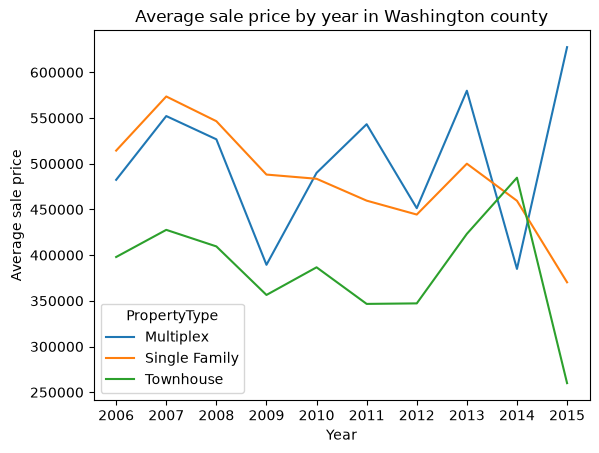

In [11]:
average_prices.plot(kind="line")
plt.xlabel("Year")
plt.ylabel("Average sale price")
plt.title("Average sale price by year in Washington county")
plt.xticks(average_prices.index)
plt.show

Results

Overall, the sale prices have fluctuated for all property types. Troughout the nine years period, the sale prices for "Multiplex" have increased but decreased for "Single Family" and "Townhouse" properties

8. Scatterplots to get an idea of the relationship between "Total living area" and "Sale price"

(7482, 3)
     PropertyType  SalePrice  SqFtTotLiving
1   Single Family    1000000           3764
8   Single Family     220400            990
14  Single Family     605000           2120
16  Single Family     455000           1500
21  Single Family     490000           1530


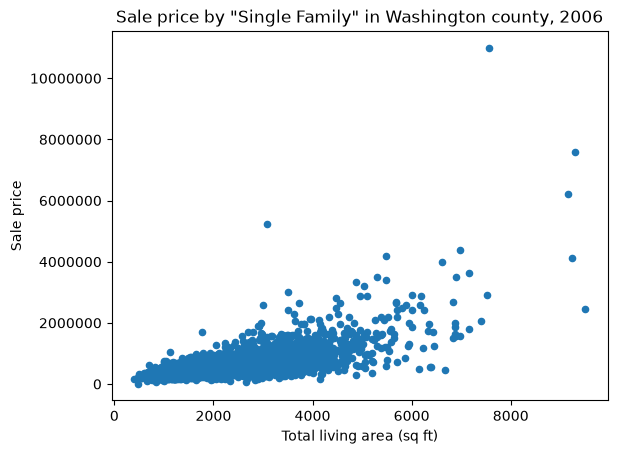

(118, 3)
    PropertyType  SalePrice  SqFtTotLiving
9      Multiplex     437500           1980
241    Multiplex     600000           3930
320    Multiplex     832000           2110
541    Multiplex     422000           2480
669    Multiplex     300000           1840


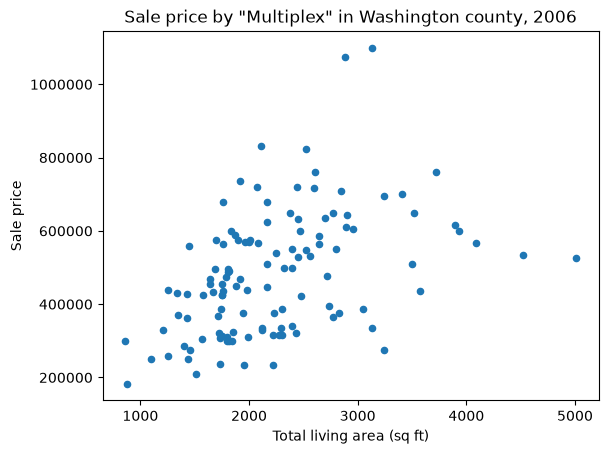

(508, 3)
    PropertyType  SalePrice  SqFtTotLiving
218    Townhouse     399000           1440
617    Townhouse     414850           1445
618    Townhouse     395000           1445
621    Townhouse     425000           1600
622    Townhouse     395000           1445


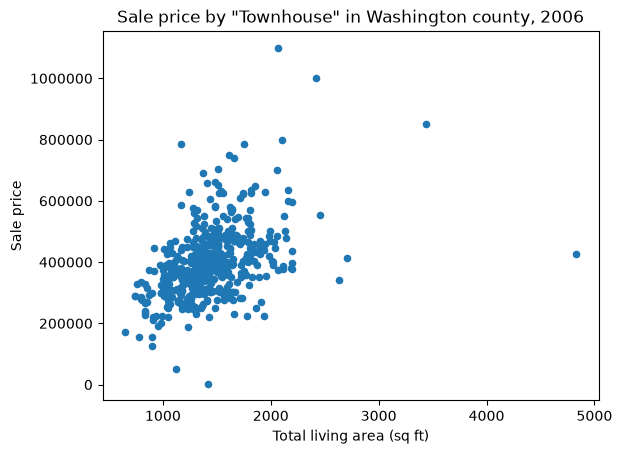

In [12]:
def price_by_size_analyzer(df, property_type):
    for type, title in property_type.items():
        sale_price_by_size = df[
            (df["PropertyType"] == type) & (df["DocumentDate"] == 2006)][["PropertyType", "SalePrice", "SqFtTotLiving"]]
        print(sale_price_by_size.shape)
        print(sale_price_by_size.head())
        sale_price_by_size.plot(
            kind="scatter",
            x = "SqFtTotLiving",
            y = "SalePrice")
        plt.xlabel("Total living area (sq ft)")
        plt.ylabel("Sale price")
        plt.title(title)
        plt.ticklabel_format(style='plain', axis='y')
        plt.show()

price_by_size_analyzer(
    data1,
    property_type = {
    "Single Family": 'Sale price by "Single Family" in Washington county, 2006',
    "Multiplex" : 'Sale price by "Multiplex" in Washington county, 2006',
    "Townhouse" : 'Sale price by "Townhouse" in Washington county, 2006'
    }
)

9. The scatterplots suggest an approximately linear relationship between the total living area of the properties and their sale prices; therefore, a simple linear regression model can result in a better understanding of the relationship.


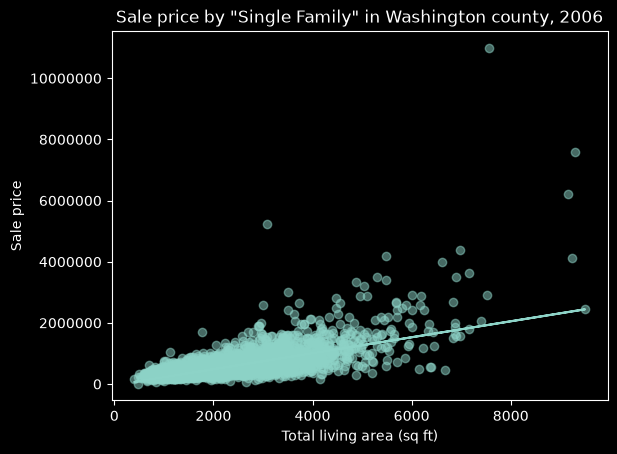

Single Family
Linear regression equation: SalePrice = -38065.96 + 261.24 × SqFtTotLiving
coefficient of determination r²: 0.478
p-value: 0.0000


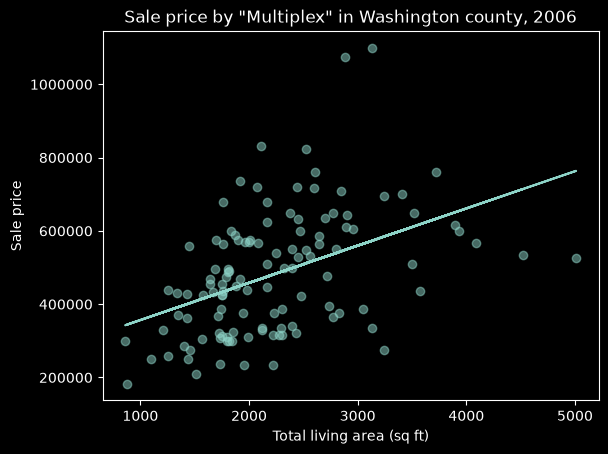

Multiplex
Linear regression equation: SalePrice = 255178.97 + 101.54 × SqFtTotLiving
coefficient of determination r²: 0.194
p-value: 0.0000


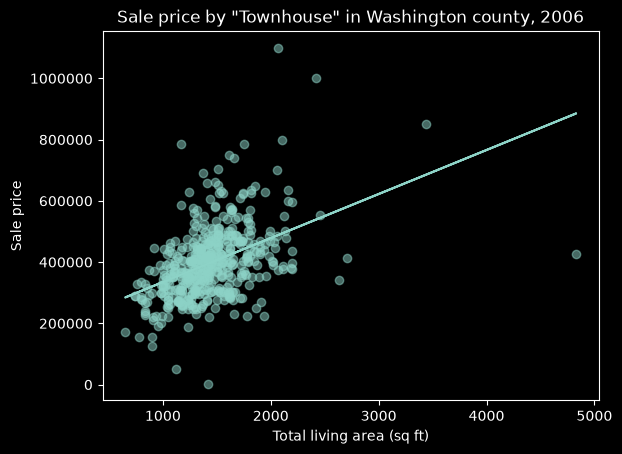

Townhouse
Linear regression equation: SalePrice = 191078.42 + 143.73 × SqFtTotLiving
coefficient of determination r²: 0.195
p-value: 0.0000


In [24]:
def apply_regression(df, property_type):
    for type, title in property_type.items():
        sale_price_by_size = df[
            (df["PropertyType"] == type) & (df["DocumentDate"] == 2006)][["PropertyType", "SalePrice", "SqFtTotLiving"]]
        x = sale_price_by_size['SqFtTotLiving']
        y = sale_price_by_size['SalePrice']
        result = linregress(x,y)
        linear_regress_line = result.intercept + result.slope * x
        plt.scatter(x,y, alpha=0.5)
        plt.plot(x, linear_regress_line)
        plt.xlabel("Total living area (sq ft)")
        plt.ylabel("Sale price")
        plt.title(title)
        plt.ticklabel_format(style='plain', axis='y')
        # plt.style.use('dark_background')
        plt.show()
        print(type)
        print(
    f"Linear regression equation: "
    f"SalePrice = {result.intercept:.2f} + {result.slope:.2f} × SqFtTotLiving"
)
        print(f'coefficient of determination r²: {result.rvalue**2:.3f}')
        print(f'p-value: {result.pvalue:.4f}')



apply_regression(
    data1,
    property_type = {
    "Single Family": 'Sale price by "Single Family" in Washington county, 2006',
    "Multiplex" : 'Sale price by "Multiplex" in Washington county, 2006',
    "Townhouse" : 'Sale price by "Townhouse" in Washington county, 2006'
    }
)

10. Testing assumptions of regression for better interpretation of the results

Assumptions to be tested: Linearity, Independence of errors, Normality of error, Equal variance

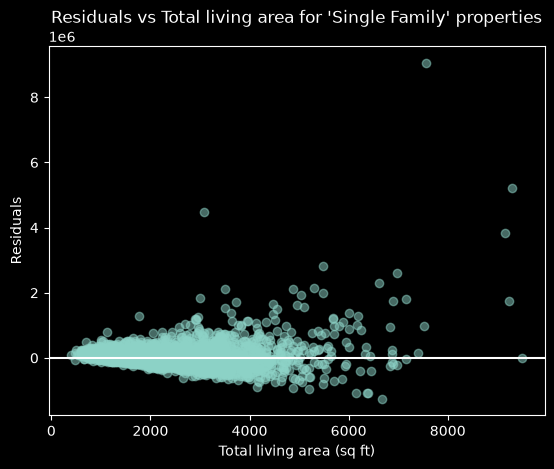

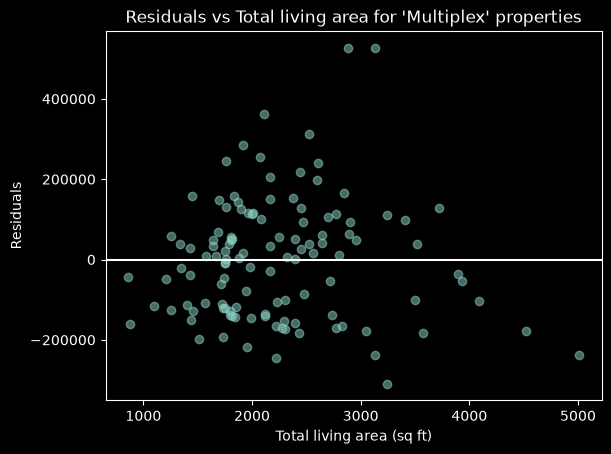

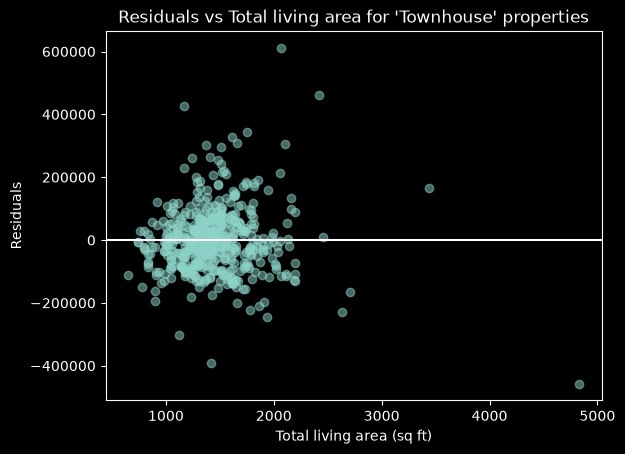

In [21]:
def linearity_test(df, property_types):
    for property_type in property_types:
        sale_price_by_size = df[
            (df["PropertyType"] == property_type) & (df["DocumentDate"] == 2006)][["PropertyType", "SalePrice", "SqFtTotLiving"]]
        result = linregress(sale_price_by_size['SqFtTotLiving'],sale_price_by_size['SalePrice'])
        predicted = result.intercept + result.slope * sale_price_by_size['SqFtTotLiving']
        residuals = sale_price_by_size['SalePrice'] - predicted
        plt.scatter(sale_price_by_size['SqFtTotLiving'], residuals, alpha=0.5)
        plt.axhline(0)
        plt.xlabel("Total living area (sq ft)")
        plt.ylabel("Residuals")
        plt.title(f"Residuals vs Total living area for '{property_type}' properties")
        plt.show()
linearity_test(data1, property_types=["Single Family", "Multiplex", "Townhouse"])

Observation

The scatterplots present no apparent pattern; the relationship between the total living area and the residuals appear to be linear.

 Independence of errors

 The error can be assumed to be independent because the observations represent different properties in 2006 (dropped the duplicates on step  of the analysis)


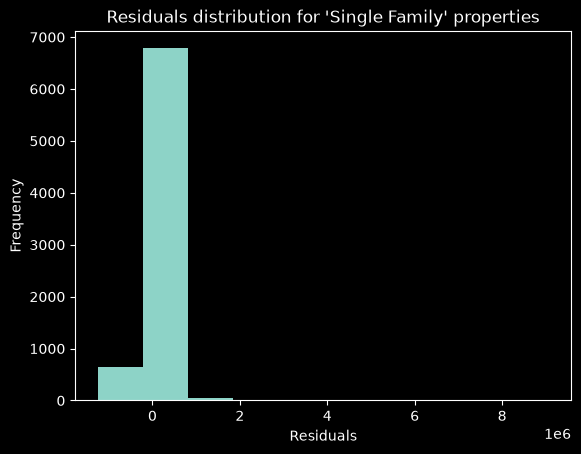

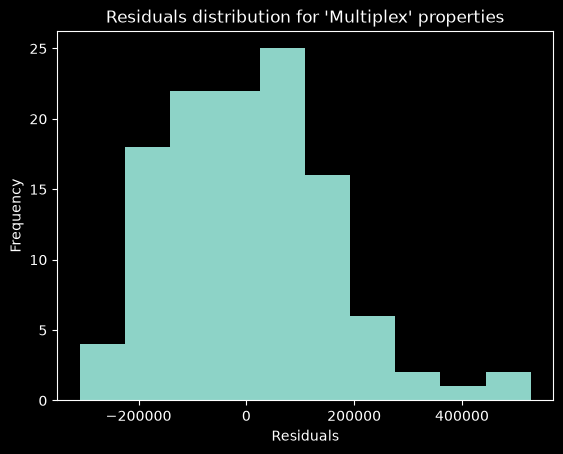

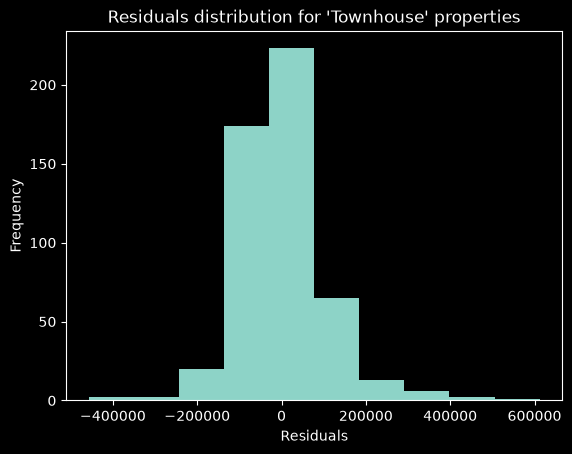

In [15]:
def normality_test(df, property_types):
    for property_type in property_types:
        sale_price_by_size = df[
            (df["PropertyType"] == property_type) & (df["DocumentDate"] == 2006)][["PropertyType", "SalePrice", "SqFtTotLiving"]]
        result = linregress(sale_price_by_size['SqFtTotLiving'],sale_price_by_size['SalePrice'])
        predicted = result.intercept + result.slope * sale_price_by_size['SqFtTotLiving']
        residuals = sale_price_by_size['SalePrice'] - predicted
        plt.hist(residuals)
        # plt.axhline(0)
        plt.xlabel("Residuals")
        plt.ylabel("Frequency")
        plt.title(f"Residuals distribution for '{property_type}' properties")
        plt.show()

normality_test(data1, property_types=["Single Family", "Multiplex", "Townhouse"])

Observation

The residuals are not perfectly normally distributed but the high number of observations make the regression inference less sensitive to moderate non normality that we read on the histograms above.

Equal variance test

The plots (living area vs residuals) suggest unequal variance because the variability the residuals increases as the living area increase

Findings

Based on results of the simple linear regression (step 9), here are the conclusions about the p-value and the coefficient of determination r²
found:

At a 5% significance level (α = 0.05), all p-values are below α, indicating a statistically significant linear relationship between total living area and sale price for all property types in 2006. However, the unequal variance observed in the residuals vs total living area plot is a limitation of the analysis.

Moreover, the variability in total living area explained 47.8% of the variability in sale price for "Single Family" properties whereas for the the "Multiplex" and "Townhouse" properties, the variability in total living area explained only 19.4% and 19.5% of the variability in sale price respectively.